<a href="https://colab.research.google.com/github/IsabelaZa26/Seguimiento-1/blob/main/Getting_started_with_google_colab_ai.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [108]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**2. Cargar base de datos**

In [109]:
ruta = '/content/drive/MyDrive/IMD/archivo.csv'

In [110]:
import pandas as pd
import sqlite3
import numpy as np
import os

In [111]:
ruta = '/content/drive/MyDrive/IMD/GlobalLandTemperaturesByCountry.csv'
df = pd.read_csv(ruta)
df.head()

,dt,AverageTemperature,AverageTemperatureUncertainty,Country
0,1743-11-01,4.384,2.294,Åland
1,1743-12-01,NaN,NaN,Åland
2,1744-01-01,NaN,NaN,Åland
3,1744-02-01,NaN,NaN,Åland
4,1744-03-01,NaN,NaN,Åland


**3. Explorar la estructura de la base**

Número de registros

In [112]:
print("Dimensiones:", df.shape)
print("\nColumnas:")
print(df.columns)

Dimensiones: (577462, 4)

Columnas:
Index(['dt', 'AverageTemperature', 'AverageTemperatureUncertainty', 'Country'], dtype='object')


Número de paises

In [113]:
print("\nNúmero de países:", df['Country'].nunique())


Número de países: 243


fecha mínima y máxima

In [114]:
print("Fecha mínima:", df['dt'].min())
print("Fecha máxima:", df['dt'].max())

Fecha mínima: 1743-11-01
Fecha máxima: 2013-09-01


cantidad de valores faltantes en las variables principales.

In [115]:
print("\nValores faltantes:")
print(df.isnull().sum())


Valores faltantes:
dt                                   0
AverageTemperature               32651
AverageTemperatureUncertainty    31912
Country                              0
dtype: int64


En la etapa de exploración inicial se revisó la presencia de valores faltantes en las variables principales de la base de temperatura. Estos faltantes fueron tenidos en cuenta durante el proceso de agregación anual, ya que los cálculos de temperatura promedio, mínima, máxima e incertidumbre se realizaron utilizando las observaciones disponibles en cada combinación de país y año. Es decir, no se realizó una imputación de valores faltantes, sino que se trabajó con la información efectivamente reportada en la base.

**4. Extraer el año a partir de la variable dt**

In [116]:
df['dt'] = pd.to_datetime(df['dt'], errors='coerce')
df['Year'] = df['dt'].dt.year

df.head()
print(df[['dt', 'Year']].head())

          dt  Year
0 1743-11-01  1743
1 1743-12-01  1743
2 1744-01-01  1744
3 1744-02-01  1744
4 1744-03-01  1744


**Cargar la base en SQLite**

In [117]:
conn = sqlite3.connect('clima.db')

df.to_sql('temperaturas', conn, if_exists='replace', index=False)

577462

**Tabla agregada por país y año**

In [119]:
conn.execute("DROP TABLE IF EXISTS temperatura_anual;")

query_agregada = """
CREATE TABLE temperatura_anual AS
SELECT
    Country,
    Year,
    AVG(AverageTemperature) AS temp_promedio_anual,
    MIN(AverageTemperature) AS temp_min_anual,
    MAX(AverageTemperature) AS temp_max_anual,
    COUNT(AverageTemperature) AS num_observaciones,
    AVG(AverageTemperatureUncertainty) AS incertidumbre_promedio_anual
FROM temperaturas
WHERE Year IS NOT NULL
GROUP BY Country, Year
ORDER BY Country, Year;
"""
conn.execute(query_agregada)
conn.commit()

In [120]:
pd.read_sql_query("SELECT * FROM temperatura_anual LIMIT 10;", conn)

,Country,Year,temp_promedio_anual,temp_min_anual,temp_max_anual,num_observaciones,incertidumbre_promedio_anual
0,Afghanistan,1838,18.379571,7.475,26.877,7,2.756000
1,Afghanistan,1839,NaN,NaN,NaN,0,NaN
2,Afghanistan,1840,13.413455,0.735,27.739,11,2.502000
3,Afghanistan,1841,13.997600,-0.883,27.104,10,2.452100
4,Afghanistan,1842,15.154667,3.330,25.798,9,2.381222
5,Afghanistan,1843,13.756250,0.674,26.748,12,2.353083
6,Afghanistan,1844,13.148750,0.959,26.576,12,2.235417
7,Afghanistan,1845,13.305833,0.421,26.383,12,2.370917
8,Afghanistan,1846,14.030833,1.194,27.278,12,2.442250
9,Afghanistan,1847,13.475583,-0.402,27.223,12,2.457833


Número de registros por país

In [121]:
q1 = """
SELECT Country, COUNT(*) AS total_registros
FROM temperaturas
GROUP BY Country
ORDER BY total_registros DESC
LIMIT 10;
"""
pd.read_sql_query(q1, conn)

,Country,total_registros
0,Åland,3239
1,United Kingdom (Europe),3239
2,United Kingdom,3239
3,Ukraine,3239
4,Switzerland,3239
5,Sweden,3239
6,Spain,3239
7,Slovenia,3239
8,Slovakia,3239
9,Serbia,3239


Años cubiertos por país

In [122]:
q2 = """
SELECT Country,
       MIN(Year) AS primer_año,
       MAX(Year) AS ultimo_año
FROM temperaturas
GROUP BY Country
ORDER BY Country;
"""
pd.read_sql_query(q2, conn).head(5)

,Country,primer_año,ultimo_año
0,Afghanistan,1838,2013
1,Africa,1850,2013
2,Albania,1743,2013
3,Algeria,1787,2013
4,American Samoa,1867,2013


Países con mayor temperatura promedio anual

In [123]:
q3 = """
SELECT Country,
       AVG(temp_promedio_anual) AS promedio_historico
FROM temperatura_anual
GROUP BY Country
ORDER BY promedio_historico DESC
LIMIT 10;
"""
pd.read_sql_query(q3, conn)

,Country,promedio_historico
0,Djibouti,28.821865
1,Mali,28.440748
2,Burkina Faso,28.070511
3,Senegal,27.963677
4,Aruba,27.919836
5,United Arab Emirates,27.654288
6,Mauritania,27.582404
7,Gambia,27.534722
8,Niger,27.444111
9,Curaçao,27.353157


Países con mayor variación de temperatura

In [124]:
q4 = """
SELECT Country,
       MAX(temp_promedio_anual) - MIN(temp_promedio_anual) AS rango_temperatura
FROM temperatura_anual
GROUP BY Country
ORDER BY rango_temperatura DESC
LIMIT 10;
"""
pd.read_sql_query(q4, conn)

,Country,rango_temperatura
0,Canada,23.408714
1,Russia,19.713667
2,Kazakhstan,17.726250
3,North America,17.628667
4,Kuwait,15.618667
5,Uzbekistan,15.340250
6,United States,15.005667
7,Turkmenistan,14.920500
8,Algeria,14.872667
9,Jordan,14.373500


completitud por país

In [125]:
q5 = """
SELECT Country,
       COUNT(*) AS total_pais_año,
       AVG(num_observaciones) AS promedio_obs_por_año
FROM temperatura_anual
GROUP BY Country
ORDER BY total_pais_año DESC;
"""
pd.read_sql_query(q5, conn).head(10)

,Country,total_pais_año,promedio_obs_por_año
0,Åland,271,11.682657
1,United Kingdom (Europe),271,11.682657
2,United Kingdom,271,11.682657
3,Ukraine,271,11.682657
4,Switzerland,271,11.682657
5,Sweden,271,11.682657
6,Spain,271,11.682657
7,Slovenia,271,11.682657
8,Slovakia,271,11.682657
9,Serbia,271,11.682657


**Visualizador temperatura promedio por año**

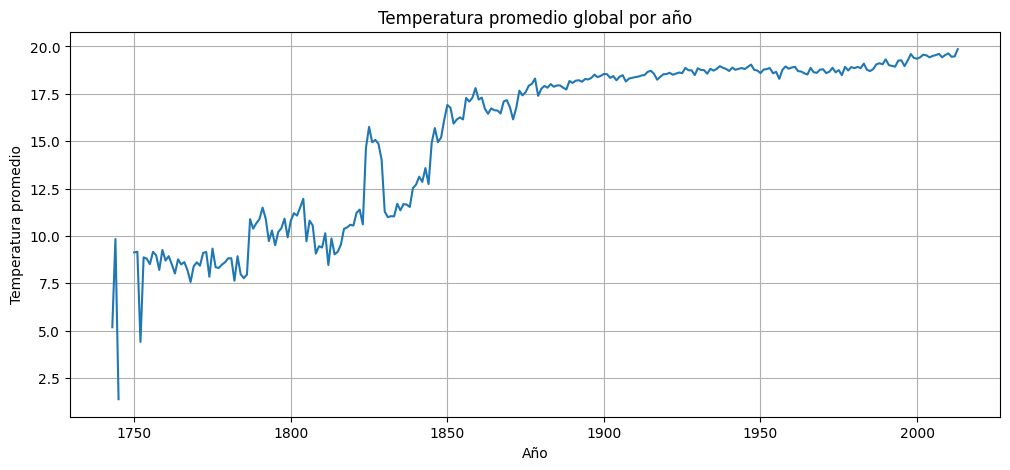

In [126]:
import matplotlib.pyplot as plt

temp_global = pd.read_sql_query("""
SELECT Year, AVG(temp_promedio_anual) AS temp_global
FROM temperatura_anual
GROUP BY Year
ORDER BY Year;
""", conn)

plt.figure(figsize=(12,5))
plt.plot(temp_global['Year'], temp_global['temp_global'])
plt.title('Temperatura promedio global por año')
plt.xlabel('Año')
plt.ylabel('Temperatura promedio')
plt.grid(True)
plt.show()

**Países con mayor temperatura promedio**

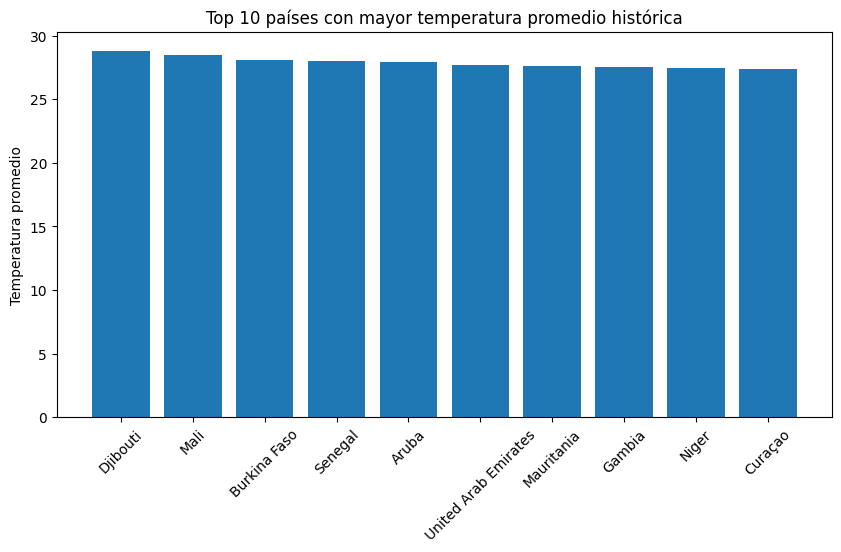

In [127]:
top_calidos = pd.read_sql_query("""
SELECT Country, AVG(temp_promedio_anual) AS promedio_historico
FROM temperatura_anual
GROUP BY Country
ORDER BY promedio_historico DESC
LIMIT 10;
""", conn)

plt.figure(figsize=(10,5))
plt.bar(top_calidos['Country'], top_calidos['promedio_historico'])
plt.title('Top 10 países con mayor temperatura promedio histórica')
plt.xticks(rotation=45)
plt.ylabel('Temperatura promedio')
plt.show()

**4.2 Parte abierta (exploración propia)**

Para la sección abierta del proyecto, se optó por la base de datos de Población total del Banco Mundial, la cual proporciona datos anuales acerca del número de habitantes de diversos países. Se eligió este indicador para añadir al análisis de la temperatura media anual y examinar, de manera descriptiva, si hay patrones claros entre el cambio de temperatura y el aumento de la población a través del tiempo. A partir de esta fuente, se intentó combinar la información demográfica con los datos climáticos utilizando las variables de país y año, con el objetivo de crear una tabla final que permitiera efectuar consultas, comparativas y visualizaciones relevantes para la investigación.

In [128]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [129]:
zip_path = '/content/drive/MyDrive/IMD/API_SP.POP.TOTL_DS2_en_csv_v2_58.zip'

In [130]:
import zipfile

zip_path = 'API_SP.POP.TOTL_DS2_en_csv_v2_58.zip'

with zipfile.ZipFile(zip_path, 'r') as z:
    print(z.namelist())
    with z.open('API_SP.POP.TOTL_DS2_en_csv_v2_58.csv') as f:
        poblacion = pd.read_csv(f, skiprows=4)

poblacion.head()

['Metadata_Indicator_API_SP.POP.TOTL_DS2_en_csv_v2_58.csv', 'API_SP.POP.TOTL_DS2_en_csv_v2_58.csv', 'Metadata_Country_API_SP.POP.TOTL_DS2_en_csv_v2_58.csv']


,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,"Population, total",SP.POP.TOTL,54922.0,55578.0,56320.0,57002.0,57619.0,58190.0,...,108735.0,108908.0,109203.0,108587.0,107700.0,107310.0,107359.0,107995.0,NaN,NaN
1,Africa Eastern and Southern,AFE,"Population, total",SP.POP.TOTL,130075728.0,133534923.0,137171659.0,140945536.0,144904094.0,149033472.0,...,640058741.0,657801085.0,675950189.0,694446100.0,713090928.0,731821393.0,750491370.0,769280888.0,NaN,NaN
2,Afghanistan,AFG,"Population, total",SP.POP.TOTL,9035043.0,9214083.0,9404406.0,9604487.0,9814318.0,10036008.0,...,35688935.0,36743039.0,37856121.0,39068979.0,40000412.0,40578842.0,41454761.0,42647492.0,NaN,NaN
3,Africa Western and Central,AFW,"Population, total",SP.POP.TOTL,97630925.0,99706674.0,101854756.0,104089175.0,106388440.0,108772632.0,...,440882906.0,452195915.0,463365429.0,474569351.0,485920997.0,497387180.0,509398589.0,521764076.0,NaN,NaN
4,Angola,AGO,"Population, total",SP.POP.TOTL,5231654.0,5301583.0,5354310.0,5408320.0,5464187.0,5521981.0,...,30234839.0,31297155.0,32375632.0,33451132.0,34532429.0,35635029.0,36749906.0,37885849.0,NaN,NaN


Cambiar posicion de hancho a largo

In [131]:
poblacion_larga = poblacion.melt(
    id_vars=['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code'],
    var_name='Year',
    value_name='Population'
)

poblacion_larga.head()

,Country Name,Country Code,Indicator Name,Indicator Code,Year,Population
0,Aruba,ABW,"Population, total",SP.POP.TOTL,1960,54922.0
1,Africa Eastern and Southern,AFE,"Population, total",SP.POP.TOTL,1960,130075728.0
2,Afghanistan,AFG,"Population, total",SP.POP.TOTL,1960,9035043.0
3,Africa Western and Central,AFW,"Population, total",SP.POP.TOTL,1960,97630925.0
4,Angola,AGO,"Population, total",SP.POP.TOTL,1960,5231654.0


Limpieza de nombres

In [132]:
poblacion_larga = poblacion_larga.rename(columns={
    'Country Name': 'Country',
    'Country Code': 'Country_Code',
    'Indicator Name': 'Indicator_Name',
    'Indicator Code': 'Indicator_Code'
})

poblacion_larga['Year'] = pd.to_numeric(poblacion_larga['Year'], errors='coerce')
poblacion_larga['Population'] = pd.to_numeric(poblacion_larga['Population'], errors='coerce')

poblacion_larga = poblacion_larga.dropna(subset=['Year'])
poblacion_larga['Year'] = poblacion_larga['Year'].astype(int)

poblacion_larga.head()

,Country,Country_Code,Indicator_Name,Indicator_Code,Year,Population
0,Aruba,ABW,"Population, total",SP.POP.TOTL,1960,54922.0
1,Africa Eastern and Southern,AFE,"Population, total",SP.POP.TOTL,1960,130075728.0
2,Afghanistan,AFG,"Population, total",SP.POP.TOTL,1960,9035043.0
3,Africa Western and Central,AFW,"Population, total",SP.POP.TOTL,1960,97630925.0
4,Angola,AGO,"Population, total",SP.POP.TOTL,1960,5231654.0


In [133]:
print("Dimensiones:", poblacion_larga.shape)
print("\nValores faltantes:")
print(poblacion_larga.isnull().sum())

print("\nAño mínimo:", poblacion_larga['Year'].min())
print("Año máximo:", poblacion_larga['Year'].max())
print("Número de países:", poblacion_larga['Country'].nunique())

Dimensiones: (17556, 6)

Valores faltantes:
Country             0
Country_Code        0
Indicator_Name      0
Indicator_Code      0
Year                0
Population        361
dtype: int64

Año mínimo: 1960
Año máximo: 2025
Número de países: 266


## Transformación de la base de población

La base de población del Banco Mundial se encontraba en formato ancho, es decir, con una columna para cada año. Para poder integrarla con la tabla anual de temperatura, se realizó un proceso de pivoteo a formato largo, obteniendo una estructura con las variables país, código de país, nombre del indicador, código del indicador, año y valor de población. Posteriormente, se ajustaron los tipos de datos para facilitar la unión por país y año.

In [134]:
poblacion_larga.to_sql('poblacion_api', conn, if_exists='replace', index=False)

17556

Integración de temperatura con población

In [135]:
conn.execute("DROP TABLE IF EXISTS tabla_final;")

query_join = """
CREATE TABLE tabla_final AS
SELECT
    t.Country,
    t.Year,
    t.temp_promedio_anual,
    t.temp_min_anual,
    t.temp_max_anual,
    t.num_observaciones,
    t.incertidumbre_promedio_anual,
    p.Country_Code,
    p.Indicator_Name,
    p.Indicator_Code,
    p.Population
FROM temperatura_anual t
INNER JOIN poblacion_api p
    ON t.Country = p.Country
   AND t.Year = p.Year;
"""
conn.execute(query_join)
conn.commit()

In [136]:
pd.read_sql_query("""
SELECT MIN(Year) AS anio_minimo,
       MAX(Year) AS anio_maximo
FROM tabla_final;
""", conn)

,anio_minimo,anio_maximo
0,1960,2013


## Integración de la información

Una vez transformada la base de población a formato largo y ajustados sus nombres de variables y tipos de datos, se realizó la integración con la tabla anual de temperatura mediante las variables país y año. Para construir la tabla final utilizada en el análisis comparativo, se empleó una unión interna (`INNER JOIN`), de modo que solo se conservaron los registros con correspondencia en ambas fuentes. Esta decisión permitió obtener una base consistente para comparar temperatura y población, evitando la presencia de valores nulos en el indicador demográfico. En consecuencia, el universo de análisis posterior a la integración no es exactamente el mismo que el de la base climática original, ya que depende de la intersección entre ambas coberturas.

Registros que quedaron

In [137]:
pd.read_sql_query("""
SELECT COUNT(*) AS total_registros
FROM tabla_final;
""", conn)

,total_registros
0,8802


Registros que no tienen población

In [138]:
pd.read_sql_query("""
SELECT COUNT(*) AS registros_sin_poblacion
FROM tabla_final
WHERE Population IS NULL;
""", conn)

,registros_sin_poblacion
0,0


con población

In [139]:
pd.read_sql_query("""
SELECT COUNT(*) AS registros_con_poblacion
FROM tabla_final
WHERE Population IS NOT NULL;
""", conn)

,registros_con_poblacion
0,8802


**Análisis guiado**
1) ¿Qué países tienen las mayores temperaturas promedio anuales en el periodo analizado?

In [140]:
top_temp = pd.read_sql_query("""
SELECT Country,
       AVG(temp_promedio_anual) AS promedio_historico
FROM temperatura_anual
GROUP BY Country
ORDER BY promedio_historico DESC
LIMIT 10;
""", conn)

top_temp


,Country,promedio_historico
0,Djibouti,28.821865
1,Mali,28.440748
2,Burkina Faso,28.070511
3,Senegal,27.963677
4,Aruba,27.919836
5,United Arab Emirates,27.654288
6,Mauritania,27.582404
7,Gambia,27.534722
8,Niger,27.444111
9,Curaçao,27.353157


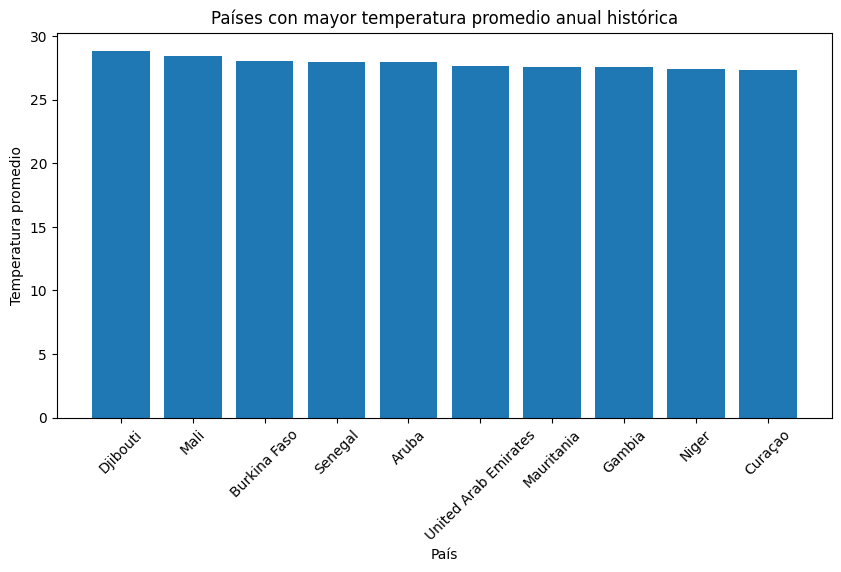

In [141]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.bar(top_temp['Country'], top_temp['promedio_historico'])
plt.title('Países con mayor temperatura promedio anual histórica')
plt.xlabel('País')
plt.ylabel('Temperatura promedio')
plt.xticks(rotation=45)
plt.show()

Para responder esta pregunta se utilizó la tabla anual de temperatura, ya que el interés principal era identificar los países con mayores niveles promedio de temperatura dentro de toda la cobertura temporal disponible en la base climática. A partir del promedio histórico de la temperatura anual, se identifican los países que registran los valores más altos en el periodo analizado.

2) ¿Qué países muestran mayor variación de temperatura a lo largo del tiempo?

Aquí usamos el rango:

**variación=max(temp_promedio_anual)−min(temp_promedio_anual)**

In [142]:
variacion_temp = pd.read_sql_query("""
SELECT Country,
       MAX(temp_promedio_anual) - MIN(temp_promedio_anual) AS variacion_temperatura
FROM temperatura_anual
GROUP BY Country
ORDER BY variacion_temperatura DESC
LIMIT 10;
""", conn)

variacion_temp

,Country,variacion_temperatura
0,Canada,23.408714
1,Russia,19.713667
2,Kazakhstan,17.726250
3,North America,17.628667
4,Kuwait,15.618667
5,Uzbekistan,15.340250
6,United States,15.005667
7,Turkmenistan,14.920500
8,Algeria,14.872667
9,Jordan,14.373500


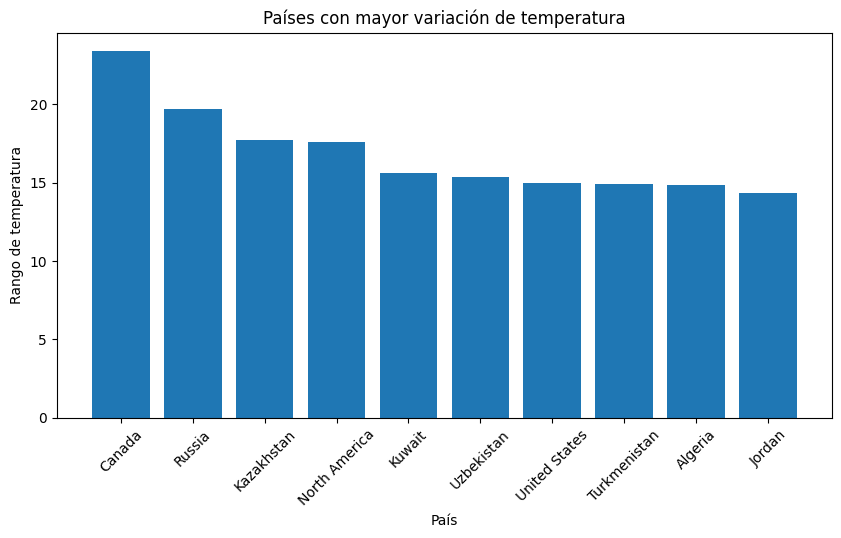

In [143]:
plt.figure(figsize=(10,5))
plt.bar(variacion_temp['Country'], variacion_temp['variacion_temperatura'])
plt.title('Países con mayor variación de temperatura')
plt.xlabel('País')
plt.ylabel('Rango de temperatura')
plt.xticks(rotation=45)
plt.show()

La variación de temperatura se calculó como la diferencia entre la temperatura promedio anual máxima y mínima registrada para cada país. Para esta pregunta también se empleó la tabla anual de temperatura, ya que permite estudiar la dinámica térmica de largo plazo sin depender de la integración con variables externas.

3) ¿Qué tan completa es la información por país y por año?

In [144]:
pd.read_sql_query("""
SELECT COUNT(DISTINCT Country) AS total_paises
FROM temperatura_anual;
""", conn)

,total_paises
0,243


In [145]:
dt_p3_pais = pd.read_sql_query("""
SELECT Country,
       COUNT(DISTINCT Year) AS anios_con_datos,
       MIN(Year) AS anio_inicial,
       MAX(Year) AS anio_final,
       AVG(num_observaciones) AS promedio_observaciones
FROM temperatura_anual
GROUP BY Country
ORDER BY anios_con_datos DESC, Country;
""", conn)

dt_p3_pais.head(15)

,Country,anios_con_datos,anio_inicial,anio_final,promedio_observaciones
0,Albania,271,1743,2013,11.682657
1,Andorra,271,1743,2013,11.682657
2,Austria,271,1743,2013,11.682657
3,Belarus,271,1743,2013,11.682657
4,Belgium,271,1743,2013,11.682657
5,Bosnia And Herzegovina,271,1743,2013,11.682657
6,Bulgaria,271,1743,2013,11.682657
7,Croatia,271,1743,2013,11.682657
8,Czech Republic,271,1743,2013,11.682657
9,Denmark (Europe),271,1743,2013,11.682657


In [146]:
dt_p3_anio = pd.read_sql_query("""
SELECT Year AS anio,
       COUNT(DISTINCT Country) AS paises_con_datos,
       ROUND(100.0 * COUNT(DISTINCT Country) /
             (SELECT COUNT(DISTINCT Country) FROM temperatura_anual), 2) AS porcentaje_completitud
FROM temperatura_anual
WHERE Year >= 1960
GROUP BY Year
ORDER BY Year;
""", conn)

dt_p3_anio.head(20)

,anio,paises_con_datos,porcentaje_completitud
0,1960,243,100.0
1,1961,243,100.0
2,1962,243,100.0
3,1963,243,100.0
4,1964,243,100.0
5,1965,243,100.0
6,1966,243,100.0
7,1967,243,100.0
8,1968,243,100.0
9,1969,243,100.0


La completitud de la información se evaluó a partir de la tabla anual de temperatura, antes de realizar la integración con la base de población. Por país, se analizó la cantidad de años con datos disponibles, junto con el rango temporal cubierto y el promedio de observaciones utilizadas en la agregación anual. Por año, se examinó el número de países con información climática registrada, con el fin de identificar cómo varía la cobertura de la base a lo largo del tiempo.

4) ¿Existen diferencias visibles entre países al comparar temperatura con población?

In [147]:
comparacion = pd.read_sql_query("""
SELECT Country, Year, temp_promedio_anual, Population
FROM tabla_final
WHERE Country IN ('Brazil', 'India', 'China', 'United States')
ORDER BY Country, Year;
""", conn)

comparacion.head(10)

,Country,Year,temp_promedio_anual,Population
0,Brazil,1960,24.752667,72388126.0
1,Brazil,1961,25.146417,74605447.0
2,Brazil,1962,24.842333,76865323.0
3,Brazil,1963,25.171583,79164235.0
4,Brazil,1964,24.734083,81488595.0
5,Brazil,1965,24.983833,83817583.0
6,Brazil,1966,25.086417,86139359.0
7,Brazil,1967,25.013667,88446124.0
8,Brazil,1968,24.631250,90741240.0
9,Brazil,1969,25.282750,93045777.0


Gráficos de temperatura por país

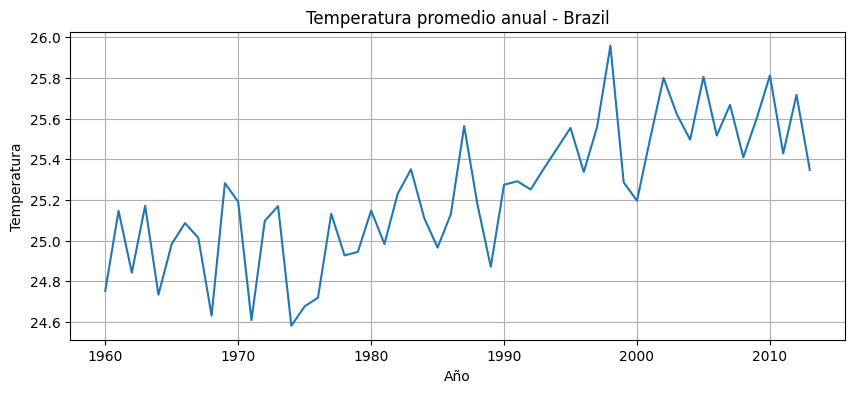

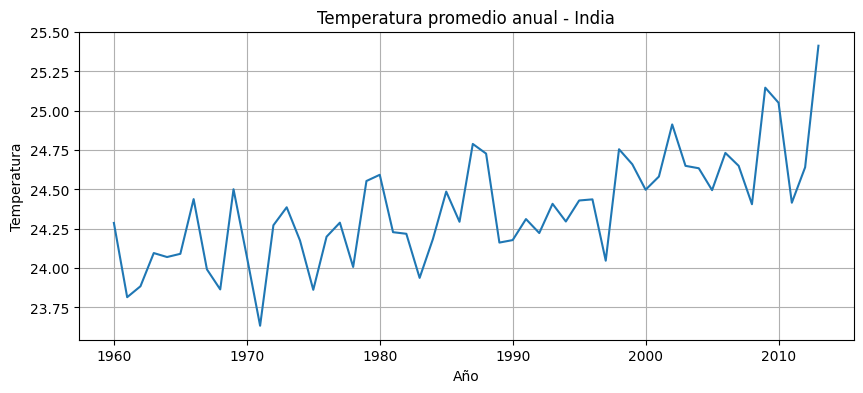

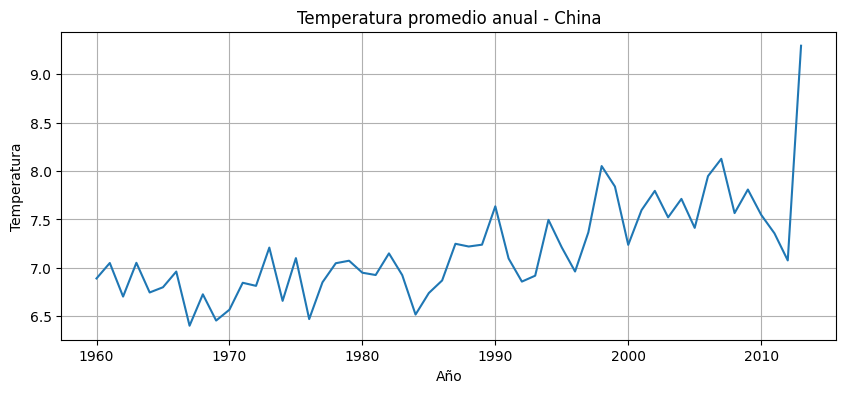

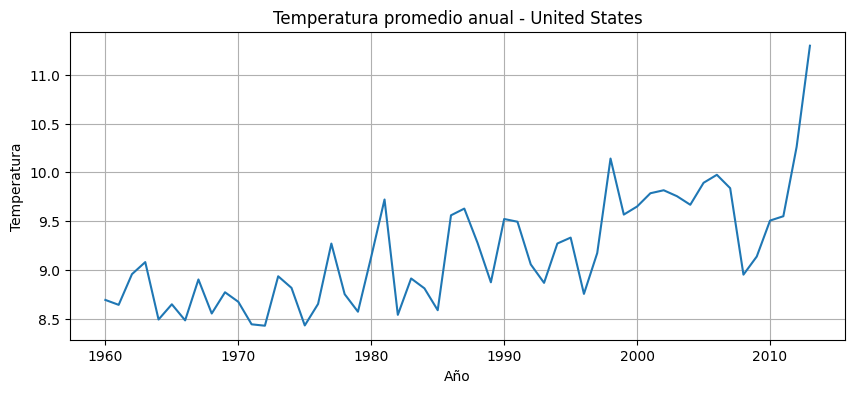

In [148]:

for pais in ['Brazil', 'India', 'China', 'United States']:
    datos = comparacion[comparacion['Country'] == pais]
    plt.figure(figsize=(10,4))
    plt.plot(datos['Year'], datos['temp_promedio_anual'])
    plt.title(f'Temperatura promedio anual - {pais}')
    plt.xlabel('Año')
    plt.ylabel('Temperatura')
    plt.grid(True)
    plt.show()

Gráficos de población por país

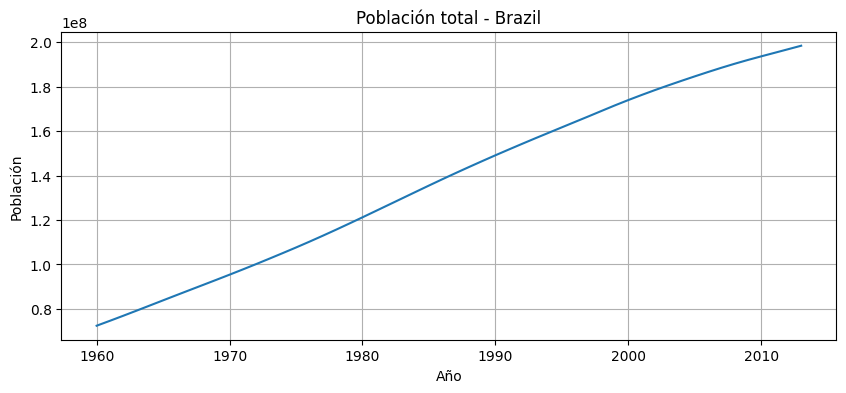

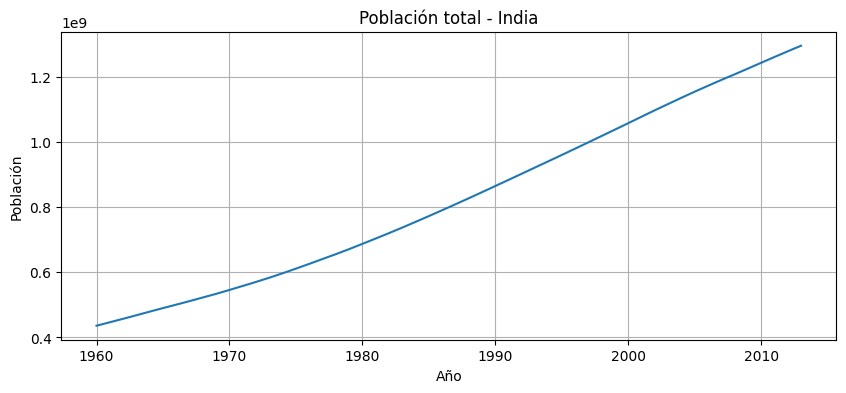

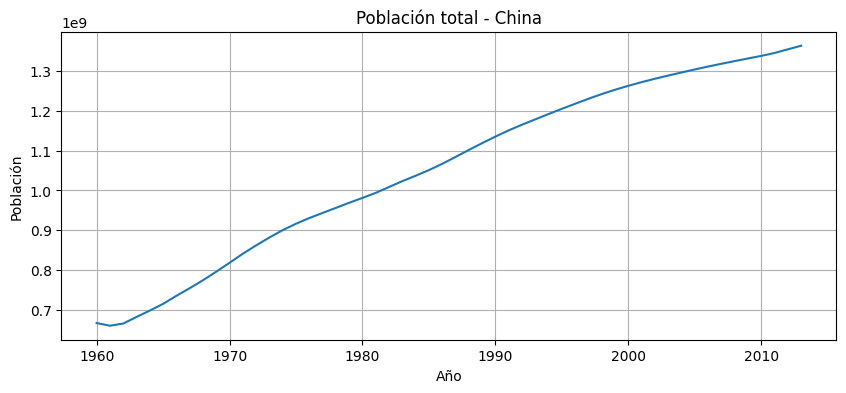

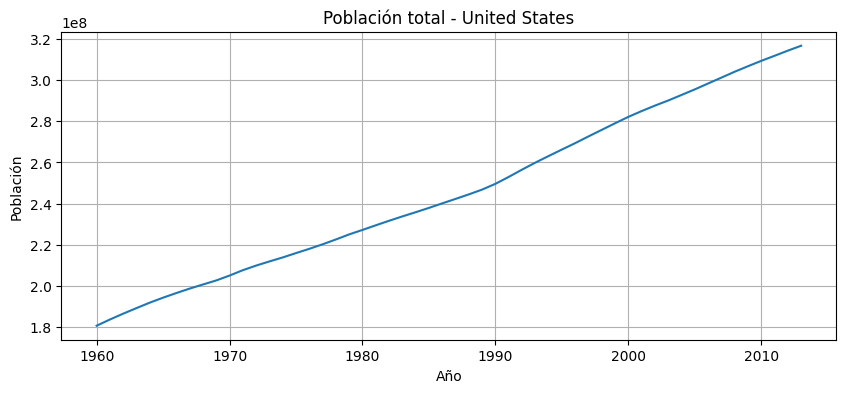

In [149]:
for pais in ['Brazil', 'India', 'China', 'United States']:
    datos = comparacion[comparacion['Country'] == pais]
    plt.figure(figsize=(10,4))
    plt.plot(datos['Year'], datos['Population'])
    plt.title(f'Población total - {pais}')
    plt.xlabel('Año')
    plt.ylabel('Población')
    plt.grid(True)
    plt.show()

Para esta comparación se utilizó la tabla final integrada, construida únicamente con los registros que presentan correspondencia en país y año entre la base de temperatura y la base de población. Esto permitió realizar una comparación directa entre ambas variables y observar diferencias visibles entre países tanto en la evolución de la temperatura promedio anual como en la dinámica poblacional.

5) ¿Qué limitaciones se observan en la integración de ambas fuentes?

Comparar número de países antes y después

In [150]:
pd.read_sql_query("""
SELECT 'temperatura_anual' AS tabla, COUNT(DISTINCT Country) AS total_paises
FROM temperatura_anual
UNION ALL
SELECT 'tabla_final' AS tabla, COUNT(DISTINCT Country) AS total_paises
FROM tabla_final;
""", conn)

,tabla,total_paises
0,temperatura_anual,243
1,tabla_final,163


Comparar rango temporal antes y después

In [151]:
pd.read_sql_query("""
SELECT 'temperatura_anual' AS tabla, MIN(Year) AS anio_min, MAX(Year) AS anio_max
FROM temperatura_anual
UNION ALL
SELECT 'tabla_final' AS tabla, MIN(Year) AS anio_min, MAX(Year) AS anio_max
FROM tabla_final;
""", conn)

,tabla,anio_min,anio_max
0,temperatura_anual,1743,2013
1,tabla_final,1960,2013


Ver qué países no quedaron en la integración

In [152]:
pd.read_sql_query("""
SELECT DISTINCT t.Country
FROM temperatura_anual t
LEFT JOIN tabla_final f
    ON t.Country = f.Country
WHERE f.Country IS NULL
ORDER BY t.Country
LIMIT 30;
""", conn)

,Country
0,Africa
1,Anguilla
2,Antarctica
3,Antigua And Barbuda
4,Asia
5,Bahamas
6,Baker Island
7,"Bonaire, Saint Eustatius And Saba"
8,Bosnia And Herzegovina
9,Burma


La principal limitación observada en la integración entre ambas fuentes es que la tabla final no conserva la totalidad de la cobertura de la base climática original, sino únicamente los registros con correspondencia en país y año con la base de población. Esto implica una reducción en el número de países y en el rango temporal disponible para el análisis conjunto. Por tanto, aunque la integración permite comparar directamente temperatura y población, también restringe el universo de estudio a la intersección entre ambas fuentes.

# **Pregunta propia de análisis**


¿Se observa una relación descriptiva entre el crecimiento poblacional y la temperatura promedio anual en los países analizados?

In [153]:
analisis_tp = pd.read_sql_query("""
SELECT Year,
       AVG(temp_promedio_anual) AS temp_media,
       AVG(Population) AS poblacion_media
FROM tabla_final
WHERE Population IS NOT NULL
GROUP BY Year
ORDER BY Year;
""", conn)

analisis_tp.head()

,Year,temp_media,poblacion_media
0,1960,18.658095,1.745006e+07
1,1961,18.713928,1.767466e+07
2,1962,18.482459,1.797880e+07
3,1963,18.478421,1.835472e+07
4,1964,18.359722,1.873256e+07


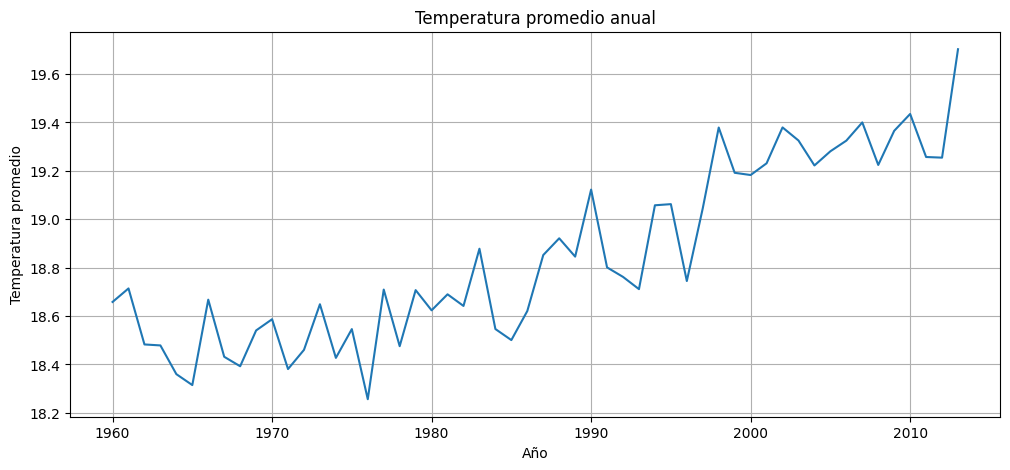

In [154]:
plt.figure(figsize=(12,5))
plt.plot(analisis_tp['Year'], analisis_tp['temp_media'])
plt.title('Temperatura promedio anual')
plt.xlabel('Año')
plt.ylabel('Temperatura promedio')
plt.grid(True)
plt.show()

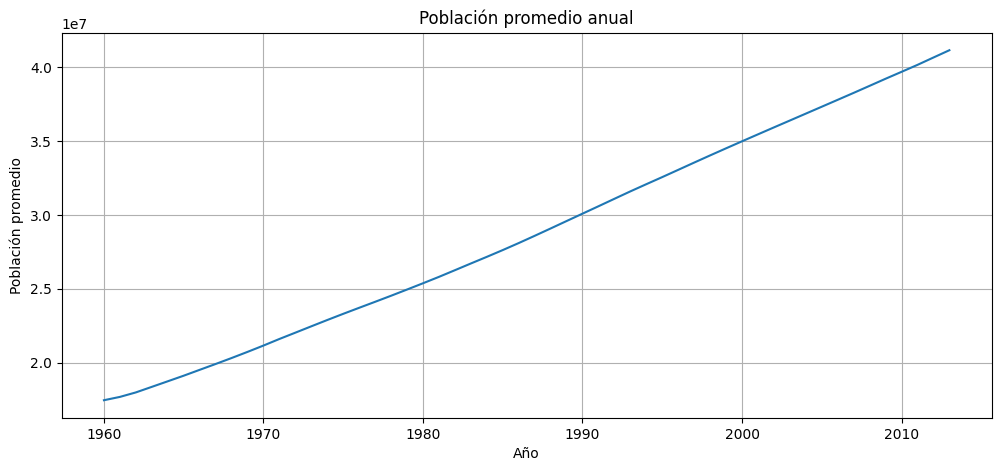

In [155]:
plt.figure(figsize=(12,5))
plt.plot(analisis_tp['Year'], analisis_tp['poblacion_media'])
plt.title('Población promedio anual')
plt.xlabel('Año')
plt.ylabel('Población promedio')
plt.grid(True)
plt.show()

En el análisis guiado se identificaron los países con mayores temperaturas promedio anuales y aquellos con mayor variación térmica a lo largo del tiempo. Asimismo, se evaluó la completitud de la información por país y por año, encontrando que la integración con el indicador de población puede presentar registros sin correspondencia debido a diferencias de cobertura o nomenclatura entre fuentes. Finalmente, la comparación entre temperatura y población permitió observar diferencias visibles entre países y patrones temporales de interés, aunque siempre dentro de un enfoque estrictamente descriptivo.

In [156]:
completitud_anio = pd.read_sql_query("""
SELECT Year,
       COUNT(*) AS total_registros,
       SUM(CASE WHEN Population IS NOT NULL THEN 1 ELSE 0 END) AS registros_con_indicador,
       ROUND(100.0 * SUM(CASE WHEN Population IS NOT NULL THEN 1 ELSE 0 END) / COUNT(*), 2) AS porcentaje_completitud
FROM tabla_final
GROUP BY Year
ORDER BY Year;
""", conn)

completitud_anio.head(10)

,Year,total_registros,registros_con_indicador,porcentaje_completitud
0,1960,163,163,100.0
1,1961,163,163,100.0
2,1962,163,163,100.0
3,1963,163,163,100.0
4,1964,163,163,100.0
5,1965,163,163,100.0
6,1966,163,163,100.0
7,1967,163,163,100.0
8,1968,163,163,100.0
9,1969,163,163,100.0


In [157]:
top_temp
variacion_temp
completitud_pais.head(10)
completitud_anio.head(10)
comparacion.head(10)

,Country,Year,temp_promedio_anual,Population
0,Brazil,1960,24.752667,72388126.0
1,Brazil,1961,25.146417,74605447.0
2,Brazil,1962,24.842333,76865323.0
3,Brazil,1963,25.171583,79164235.0
4,Brazil,1964,24.734083,81488595.0
5,Brazil,1965,24.983833,83817583.0
6,Brazil,1966,25.086417,86139359.0
7,Brazil,1967,25.013667,88446124.0
8,Brazil,1968,24.631250,90741240.0
9,Brazil,1969,25.282750,93045777.0


Comparación entre temperatura y población

Al observar la tabla final integrada, se evidencia que la unión entre la información climática y el indicador de población se realizó correctamente para varios países y años. En el caso de Brasil, por ejemplo, se dispone de registros conjuntos desde 1960, lo que permite comparar simultáneamente la temperatura promedio anual y la población total. En este periodo inicial se observa un crecimiento sostenido de la población, mientras que la temperatura promedio anual presenta fluctuaciones moderadas alrededor de un nivel relativamente estable. Esto sugiere que, al menos en esta muestra, la dinámica poblacional y la temperatura no evolucionan de forma idéntica, por lo que su relación debe interpretarse de manera descriptiva y no causal.

La tabla final obtenida confirma que fue posible integrar la información anual de temperatura con el indicador de población total del Banco Mundial mediante las variables país y año. La muestra observada evidencia que existen registros con correspondencia adecuada entre ambas fuentes, lo que permite avanzar hacia el análisis descriptivo. En consecuencia, la base final queda lista para realizar consultas, comparaciones entre países y visualizaciones sobre la relación entre temperatura y población.

In [158]:
top_temp
variacion_temp
completitud_pais.head(10)
completitud_anio.head(10)

,Year,total_registros,registros_con_indicador,porcentaje_completitud
0,1960,163,163,100.0
1,1961,163,163,100.0
2,1962,163,163,100.0
3,1963,163,163,100.0
4,1964,163,163,100.0
5,1965,163,163,100.0
6,1966,163,163,100.0
7,1967,163,163,100.0
8,1968,163,163,100.0
9,1969,163,163,100.0


Al analizar la completitud por año, se observa que en los primeros periodos de la base de temperatura, como por ejemplo entre 1743 y 1752, no existe información disponible del indicador de población, por lo que el porcentaje de completitud es de 0%. Esto evidencia una diferencia importante en la cobertura temporal de las dos fuentes integradas: mientras la base de temperatura contiene registros desde siglos anteriores, la base del Banco Mundial para población inicia en años mucho más recientes. En consecuencia, la tabla final presenta años sin correspondencia, lo cual constituye una limitación relevante para el análisis conjunto de ambas variables.

In [159]:
completitud_anio[completitud_anio['Year'] >= 1960].head(20)

,Year,total_registros,registros_con_indicador,porcentaje_completitud
0,1960,163,163,100.0
1,1961,163,163,100.0
2,1962,163,163,100.0
3,1963,163,163,100.0
4,1964,163,163,100.0
5,1965,163,163,100.0
6,1966,163,163,100.0
7,1967,163,163,100.0
8,1968,163,163,100.0
9,1969,163,163,100.0


In [160]:
completitud_anio[completitud_anio['Year'] >= 1960].tail(20)

,Year,total_registros,registros_con_indicador,porcentaje_completitud
34,1994,163,163,100.0
35,1995,163,163,100.0
36,1996,163,163,100.0
37,1997,163,163,100.0
38,1998,163,163,100.0
39,1999,163,163,100.0
40,2000,163,163,100.0
41,2001,163,163,100.0
42,2002,163,163,100.0
43,2003,163,163,100.0


La completitud mejora en los años más recientes, especialmente a partir del inicio de la cobertura del indicador de población, lo que confirma que la principal dificultad de integración se debe a la diferencia en el horizonte temporal de ambas bases.

# Conclusión

En este trabajo se construyó una base de datos en SQLite a partir de la información de temperatura global por país y de la base de población total del Banco Mundial. Esto permitió realizar procesos de lectura, transformación, pivoteo, integración y análisis descriptivo de los datos. Primero se trabajó con la tabla anual de temperatura para estudiar el comportamiento de la variable climática en toda su cobertura temporal. Después, se integró la base de población para complementar el análisis con una variable demográfica.

Los resultados muestran que existen diferencias entre países tanto en sus temperaturas promedio como en la variación que presentan a lo largo del tiempo. Además, la revisión de la completitud de la información permitió evidenciar que la integración entre ambas fuentes no es uniforme, especialmente en los años más antiguos de la base de temperatura, donde no existe correspondencia con la base de población debido a su cobertura temporal más reciente. Por esta razón, la tabla final permitió ampliar el análisis, pero también mostró limitaciones relacionadas con la disponibilidad y correspondencia de la información.

En general, el trabajo permitió responder la pregunta orientadora desde un enfoque descriptivo, identificando patrones y diferencias entre países en la evolución de la temperatura y mostrando que este análisis puede enriquecerse con indicadores complementarios como la población. Sin embargo, los resultados deben interpretarse con cautela, ya que no buscan establecer relaciones causales, sino describir comportamientos y limitaciones presentes en los datos.